# 03 — Position-Specific Drill Analysis

**Purpose**: Stratify Combine tracking features by position group.
Identify which positions show the most signal in which drills.
Begin building position-specific candidate hypotheses.

**Key question per position group**:
- WR/TE: Do route-like directional changes during the Combine correlate with NFL separation?
- Edge/DL: Does first-step burst predict NFL get-off and pressure rate?
- OL: Does lateral agility / mirror movement predict pass-protection efficiency?
- CB/S: Does acceleration/deceleration pattern predict coverage ability?

> At this stage we generate hypotheses, not final conclusions.

In [1]:
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import ensure_dirs, FIGURES_DIR, COMBINE_FEATURES_PARQUET, PLAYER_MASTER_PARQUET, DATA_PROCESSED
from src.data_loading import load_players, load_combine_results, load_combine_tracking
from src.player_mapping import assign_position_groups, build_master_player_table
from src.combine_features import aggregate_player_features
from src.statistics import spearman_with_ci, compare_groups, mannwhitney_matrix, build_correlation_summary
from src.visualization import plot_combine_vs_nfl, plot_correlation_heatmap
from src.config import MIN_SAMPLE_SIZE

logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(name)s | %(message)s')
ensure_dirs()
print('Setup complete.')

Setup complete.


## 1. Load Pre-computed Features

In [2]:
# Load from Parquet (generated in notebook 02)
if COMBINE_FEATURES_PARQUET.exists():
    features_df = pd.read_parquet(COMBINE_FEATURES_PARQUET)
    print(f'Loaded combine features: {features_df.shape}')
else:
    print('WARNING: combine_features.parquet not found — running feature extraction now...')
    from src.combine_features import extract_features_from_tracking
    tracking = load_combine_tracking()
    features_df = extract_features_from_tracking(tracking)
    features_df.to_parquet(COMBINE_FEATURES_PARQUET, index=False)

players = load_players()
players = assign_position_groups(players)
combine_results = load_combine_results(cols=None)

# Build master table
master = build_master_player_table(players, combine_results=combine_results)
master.to_parquet(PLAYER_MASTER_PARQUET, index=False)
print(f'Master player table: {master.shape}')

# Aggregate features to player level
player_features = aggregate_player_features(features_df, agg_strategy='best_attempt')

# Add position group
pos_map = players[['nfl_id', 'position', 'position_group']].drop_duplicates('nfl_id')
player_features = player_features.merge(pos_map, on='nfl_id', how='left')

print(f'Player-level features: {player_features.shape}')
print(f'Position groups present: {player_features["position_group"].value_counts().to_dict() if "position_group" in player_features.columns else "N/A"}')

INFO | src.data_loading | Loaded players: 510 rows × 10 cols | 0.1 MB | source: players.csv
WARNING | src.data_loading | players — columns with missing values:
draft_round                127
draft_pick_within_round    127
draft_overall_pick         127
WARNING | src.data_loading | combine_results: requested columns not in file (skipped): ['position']
INFO | src.data_loading | Loaded combine_results: 510 rows × 11 cols | 0.0 MB | source: combine_results.csv
WARNING | src.data_loading | combine_results — columns with missing values:
ten_yd_split                     85
forty                            86
vertical                         72
broad_jump                       87
three_cone                      330
short_shuttle                   309
bench_reps                      318
ngs_college_production_score      1
ngs_final_score                   1
INFO | src.player_mapping | Master: merged combine_results — 510 rows, 21 columns
INFO | src.player_mapping | build_master_player_table com

Loaded combine features: (3717, 52)
Master player table: (510, 21)
Player-level features: (1258, 54)
Position groups present: {'OL': 318, 'WR': 252, 'Edge': 166, 'CB': 140, 'DT': 128, 'S': 119, 'TE': 114, 'DB': 8, 'LB': 7, 'RB': 6}


## 2. Position Group Sample Sizes

Before any analysis, confirm sample sizes. We need >= 10 players per group to report findings.

In [3]:
if 'position_group' in player_features.columns:
    size_table = player_features.groupby('position_group').agg(
        n_players=('nfl_id', 'nunique'),
        n_attempts=('nfl_id', 'count'),
    ).sort_values('n_players', ascending=False)

    print('=== Position Group Sample Sizes ===')
    print(f'Minimum required for reporting: {MIN_SAMPLE_SIZE}')
    display(size_table)

    viable_groups = size_table[size_table['n_players'] >= MIN_SAMPLE_SIZE].index.tolist()
    print(f'\nViable position groups (n >= {MIN_SAMPLE_SIZE}): {viable_groups}')
else:
    viable_groups = []
    print('position_group column not found.')

=== Position Group Sample Sizes ===
Minimum required for reporting: 10


,n_players,n_attempts
position_group,,
OL,121,318
WR,106,252
Edge,66,166
CB,60,140
S,53,119
DT,52,128
TE,42,114
DB,5,8
LB,3,7



Viable position groups (n >= 10): ['OL', 'WR', 'Edge', 'CB', 'S', 'DT', 'TE']


## 3. WR / TE Analysis

**Hypothesis being tested**: WRs with higher direction-change rates and re-acceleration ability
during Combine drills will show better NFL separation and YAC.

In [4]:
# Filter to WR/TE
wr_te_feats = player_features[
    player_features['position_group'].isin(['WR', 'TE'])
].copy() if 'position_group' in player_features.columns else pd.DataFrame()

if len(wr_te_feats) >= MIN_SAMPLE_SIZE:
    print(f'WR/TE analysis population: {len(wr_te_feats)} player-drill rows')
    print(f'Unique players: {wr_te_feats["nfl_id"].nunique()}')

    # Key features for WR/TE
    wr_te_key_feats = [
        c for c in [
            'max_speed', 'total_direction_change', 'direction_change_rate',
            'best_peak_reaccel', 'best_brake_magnitude', 'best_transition_time',
            'movement_efficiency', 'mean_speed', 'n_cut_sequences',
            'first_step_acceleration', 'time_to_75pct_peak',
        ] if c in wr_te_feats.columns
    ]

    print(f'\nKey features available: {wr_te_key_feats}')

    # Summary statistics
    display(wr_te_feats[wr_te_key_feats].describe())

    # Compare WR vs TE on these features
    if 'position' in wr_te_feats.columns:
        for feat in wr_te_key_feats[:5]:
            comparison = compare_groups(wr_te_feats, 'position', feat, min_n_per_group=5)
            if not comparison.empty:
                print(f'\n{feat}:')
                display(comparison)
else:
    print(f'Insufficient WR/TE data (n={len(wr_te_feats)}, need {MIN_SAMPLE_SIZE})')

WR/TE analysis population: 366 player-drill rows
Unique players: 148

Key features available: ['max_speed', 'total_direction_change', 'direction_change_rate', 'best_peak_reaccel', 'best_brake_magnitude', 'best_transition_time', 'movement_efficiency', 'mean_speed', 'n_cut_sequences', 'first_step_acceleration', 'time_to_75pct_peak']


,max_speed,total_direction_change,direction_change_rate,best_peak_reaccel,best_brake_magnitude,best_transition_time,movement_efficiency,mean_speed,n_cut_sequences,first_step_acceleration,time_to_75pct_peak
count,366.000000,366.000000,366.000000,0.0,0.0,0.0,366.000000,366.000000,0.0,366.000000,366.000000
mean,11.401564,1943.867117,1.087013,NaN,NaN,NaN,0.502431,5.986537,NaN,2.983577,3.760383
std,5.487822,3191.796774,2.231487,NaN,NaN,NaN,0.427250,2.079745,NaN,1.144567,2.419213
min,3.892019,5.233467,0.000000,NaN,NaN,NaN,0.003041,2.258813,NaN,0.086803,1.100000
25%,8.731667,22.163145,0.000000,NaN,NaN,NaN,0.137346,4.672935,NaN,2.312312,1.800000
50%,10.391666,661.639889,0.148180,NaN,NaN,NaN,0.303799,5.974776,NaN,3.002606,2.500000
75%,11.163946,2243.607377,0.476190,NaN,NaN,NaN,1.045747,7.977911,NaN,3.710817,5.900000
max,25.794157,14389.427513,9.243697,NaN,NaN,NaN,1.142053,9.031014,NaN,6.194782,11.000000



max_speed:


,n,mean,median,std,q25,q75,min,max
group,,,,,,,,
TE,114,10.511910,9.445000,5.255839,6.873744,10.579167,3.892019,24.249016
WR,252,11.804027,10.686666,5.553029,9.807500,11.305000,4.282610,25.794157



total_direction_change:


,n,mean,median,std,q25,q75,min,max
group,,,,,,,,
TE,114,1522.740556,662.942539,2645.274917,28.293867,1432.992799,5.575584,14389.427513
WR,252,2134.376752,578.886730,3398.138090,20.797012,2309.340347,5.233467,13132.230751



direction_change_rate:


,n,mean,median,std,q25,q75,min,max
group,,,,,,,,
TE,114,0.935018,0.205793,1.832693,0.0,0.47619,0.0,9.243697
WR,252,1.155772,0.136427,2.390357,0.0,0.46875,0.0,8.484848


## 4. Edge / DL Analysis

**Hypothesis being tested**: Edge rushers with higher first-step acceleration and burst impulse
at the Combine will generate faster get-off and more quick pressure in the NFL.

In [5]:
edge_feats = player_features[
    player_features['position_group'].isin(['Edge', 'DT'])
].copy() if 'position_group' in player_features.columns else pd.DataFrame()

if len(edge_feats) >= MIN_SAMPLE_SIZE:
    print(f'Edge/DT analysis population: {len(edge_feats)} player-drill rows')
    print(f'Unique players: {edge_feats["nfl_id"].nunique()}')

    edge_key_feats = [
        c for c in [
            'first_step_acceleration', 'burst_impulse_0_5s', 'burst_impulse_0_1s',
            'time_to_50pct_peak', 'time_to_75pct_peak', 'max_acceleration',
            'max_speed', 'mean_acceleration', 'movement_efficiency',
        ] if c in edge_feats.columns
    ]

    print(f'Key features: {edge_key_feats}')
    display(edge_feats[edge_key_feats].describe())

    # Compare Edge vs DT
    if 'position_group' in edge_feats.columns:
        for feat in edge_key_feats[:4]:
            comparison = compare_groups(edge_feats, 'position_group', feat, min_n_per_group=5)
            if not comparison.empty:
                print(f'\n{feat}:')
                display(comparison)
else:
    print(f'Insufficient Edge/DT data (n={len(edge_feats)}, need {MIN_SAMPLE_SIZE})')

Edge/DT analysis population: 294 player-drill rows
Unique players: 118
Key features: ['first_step_acceleration', 'burst_impulse_0_5s', 'burst_impulse_0_1s', 'time_to_50pct_peak', 'time_to_75pct_peak', 'max_acceleration', 'max_speed', 'mean_acceleration', 'movement_efficiency']


,first_step_acceleration,burst_impulse_0_5s,burst_impulse_0_1s,time_to_50pct_peak,time_to_75pct_peak,max_acceleration,max_speed,mean_acceleration,movement_efficiency
count,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000
mean,2.910002,1.455001,0.231753,1.975510,4.017007,6.489893,8.256616,2.875037,0.737161
std,1.116713,0.558357,0.090266,1.277428,2.761544,1.257430,1.585007,0.863761,0.559356
min,0.351402,0.175701,0.002603,0.400000,1.300000,3.485342,5.063334,1.425172,0.017681
25%,2.188044,1.094022,0.180190,1.000000,1.900000,5.426779,6.921056,1.994087,0.192775
50%,2.865879,1.432940,0.228181,1.200000,2.900000,6.589517,8.288333,2.882161,0.990600
75%,3.559482,1.779741,0.282158,3.200000,5.200000,7.450807,9.494802,3.629324,1.208235
max,5.900672,2.950336,0.550268,8.800000,15.200000,9.043334,11.453333,4.671922,1.663590



first_step_acceleration:


,n,mean,median,std,q25,q75,min,max
group,,,,,,,,
DT,128,2.893134,2.794319,1.035685,2.262609,3.422537,0.503598,5.512613
Edge,166,2.923008,2.911051,1.178328,2.032246,3.800770,0.351402,5.900672



burst_impulse_0_5s:


,n,mean,median,std,q25,q75,min,max
group,,,,,,,,
DT,128,1.446567,1.397160,0.517842,1.131305,1.711269,0.251799,2.756306
Edge,166,1.461504,1.455525,0.589164,1.016123,1.900385,0.175701,2.950336



burst_impulse_0_1s:


,n,mean,median,std,q25,q75,min,max
group,,,,,,,,
DT,128,0.233358,0.226640,0.083158,0.187363,0.274807,0.035000,0.550268
Edge,166,0.230516,0.230063,0.095617,0.168409,0.290724,0.002603,0.528909



time_to_50pct_peak:


,n,mean,median,std,q25,q75,min,max
group,,,,,,,,
DT,128,1.993750,1.2,1.334388,1.0,3.300,0.4,8.8
Edge,166,1.961446,1.3,1.235616,1.0,3.175,0.5,7.8


## 5. OL Analysis

**Hypothesis being tested**: OL with better lateral agility (low efficiency in lateral drills,
high direction change rate) will allow fewer pressures.

In [6]:
ol_feats = player_features[
    player_features['position_group'] == 'OL'
].copy() if 'position_group' in player_features.columns else pd.DataFrame()

if len(ol_feats) >= MIN_SAMPLE_SIZE:
    print(f'OL analysis population: {len(ol_feats)} player-drill rows')
    print(f'Unique players: {ol_feats["nfl_id"].nunique()}')

    ol_key_feats = [
        c for c in [
            'total_direction_change', 'direction_change_rate', 'movement_efficiency',
            'best_brake_magnitude', 'best_transition_time', 'mean_deceleration',
            'max_deceleration', 'first_step_acceleration',
        ] if c in ol_feats.columns
    ]

    display(ol_feats[ol_key_feats].describe())
else:
    print(f'Insufficient OL data (n={len(ol_feats)}, need {MIN_SAMPLE_SIZE})')

OL analysis population: 318 player-drill rows
Unique players: 121


,total_direction_change,direction_change_rate,movement_efficiency,best_brake_magnitude,best_transition_time,mean_deceleration,max_deceleration,first_step_acceleration
count,316.000000,316.000000,318.000000,0.0,0.0,318.0,318.000000,318.000000
mean,1023.218802,0.269790,0.791474,NaN,NaN,0.0,0.222034,2.588186
std,1321.743254,0.238701,1.270315,NaN,NaN,0.0,0.237035,1.206181
min,5.450554,0.000000,0.031086,NaN,NaN,0.0,0.000000,0.103077
25%,28.498806,0.000000,0.172346,NaN,NaN,0.0,0.070105,1.722757
50%,376.174568,0.390843,0.399512,NaN,NaN,0.0,0.133347,2.731645
75%,2364.155040,0.440605,1.225154,NaN,NaN,0.0,0.290810,3.280512
max,4240.603071,0.857143,15.941625,NaN,NaN,0.0,1.713310,7.480193


## 6. CB / Safety Analysis

In [7]:
db_feats = player_features[
    player_features['position_group'].isin(['CB', 'S', 'DB'])
].copy() if 'position_group' in player_features.columns else pd.DataFrame()

if len(db_feats) >= MIN_SAMPLE_SIZE:
    print(f'CB/S analysis population: {len(db_feats)} rows | {db_feats["nfl_id"].nunique()} players')

    db_key_feats = [
        c for c in [
            'max_speed', 'total_direction_change', 'best_peak_reaccel',
            'first_step_acceleration', 'direction_change_rate', 'movement_efficiency',
        ] if c in db_feats.columns
    ]

    display(db_feats[db_key_feats].describe())
else:
    print(f'Insufficient CB/S data (n={len(db_feats)})')

CB/S analysis population: 267 rows | 118 players


,max_speed,total_direction_change,best_peak_reaccel,first_step_acceleration,direction_change_rate,movement_efficiency
count,267.000000,267.000000,0.0,267.000000,267.000000,267.000000
mean,9.484916,305.698777,NaN,3.232220,0.132473,0.717415
std,1.604576,473.225497,NaN,1.139056,0.214470,0.455739
min,5.662851,6.187874,NaN,0.075441,0.000000,0.022654
25%,9.095000,21.390343,NaN,2.551936,0.000000,0.223119
50%,9.576667,203.623138,NaN,2.970016,0.000000,0.996201
75%,10.912185,374.789734,NaN,3.986902,0.149658,1.067131
max,11.854232,3048.569468,NaN,7.614422,0.882353,2.167884


## 7. Cross-Position Feature Comparison

**Research question**: Are certain features universally important (across positions), or highly position-specific?

C:\Users\Ekaansh\AppData\Local\Temp\ipykernel_35176\3334594229.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid, x='position_group', y=feat, order=order, palette='Blues_d', ax=ax)


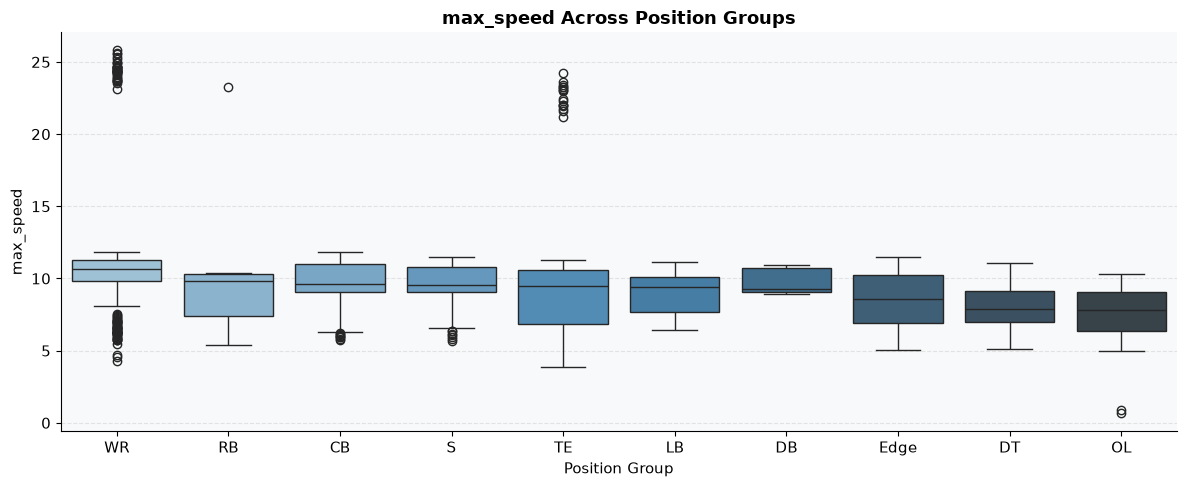

C:\Users\Ekaansh\AppData\Local\Temp\ipykernel_35176\3334594229.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid, x='position_group', y=feat, order=order, palette='Blues_d', ax=ax)


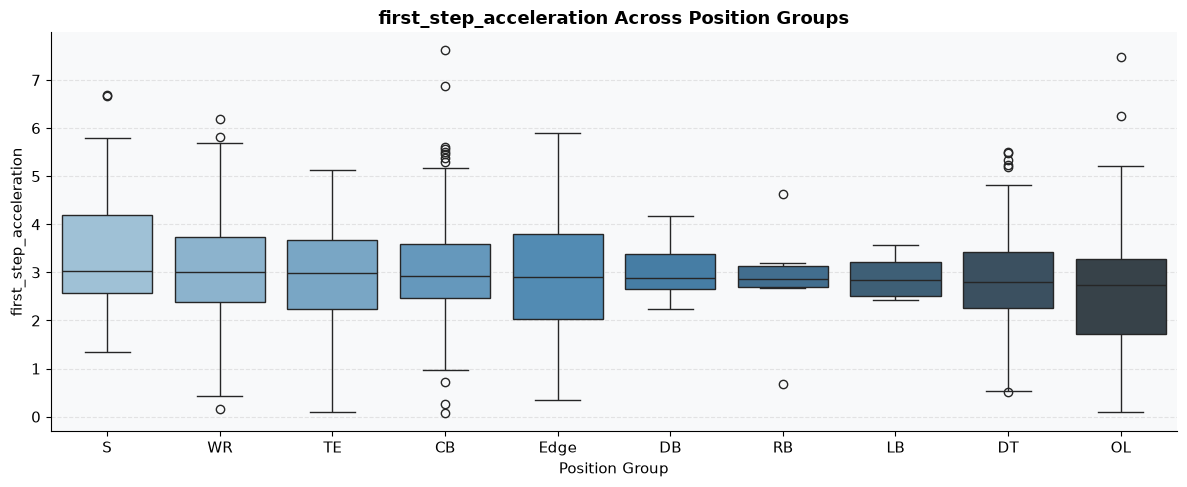

C:\Users\Ekaansh\AppData\Local\Temp\ipykernel_35176\3334594229.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid, x='position_group', y=feat, order=order, palette='Blues_d', ax=ax)


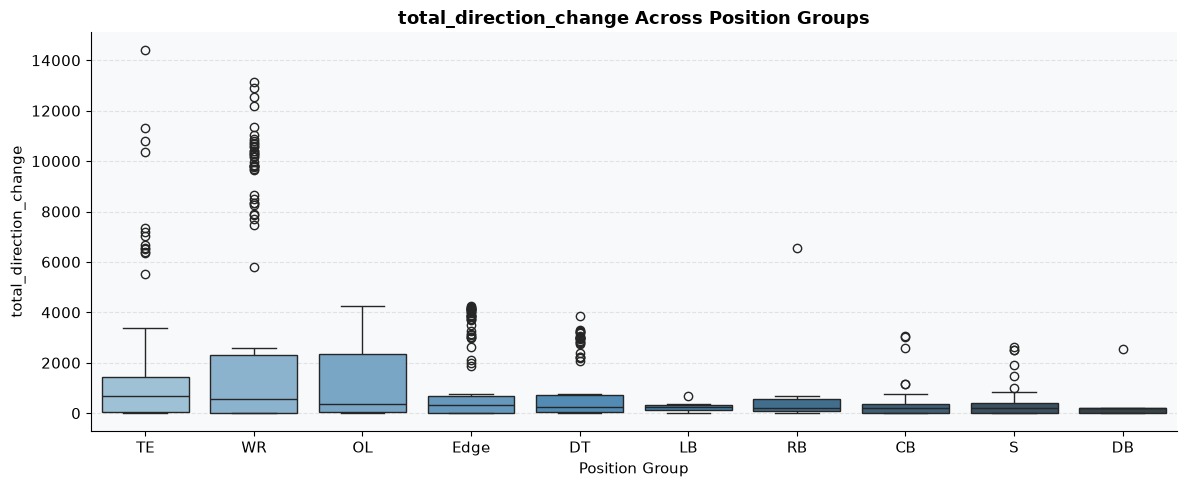

C:\Users\Ekaansh\AppData\Local\Temp\ipykernel_35176\3334594229.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid, x='position_group', y=feat, order=order, palette='Blues_d', ax=ax)


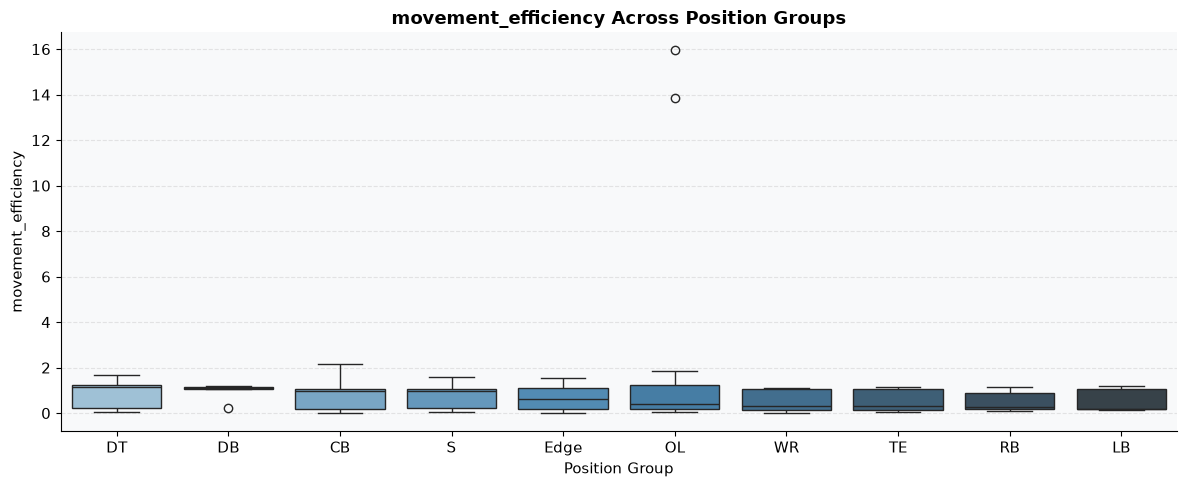

In [8]:
universal_feats = [
    c for c in ['max_speed', 'first_step_acceleration', 'total_direction_change', 'movement_efficiency']
    if c in player_features.columns
]

if 'position_group' in player_features.columns and universal_feats:
    for feat in universal_feats:
        valid = player_features[['position_group', feat]].dropna()
        if len(valid) < 10:
            continue

        order = valid.groupby('position_group')[feat].median().sort_values(ascending=False).index

        fig, ax = plt.subplots(figsize=(12, 5))
        sns.boxplot(data=valid, x='position_group', y=feat, order=order, palette='Blues_d', ax=ax)
        ax.set_title(f'{feat} Across Position Groups', fontweight='bold')
        ax.set_xlabel('Position Group')
        ax.set_ylabel(feat)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f'position_comparison_{feat}.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('Insufficient data for cross-position comparison.')

## 8. Drill-Position Heatmap

Which drills have which position groups? Are some drills exclusive to certain positions?

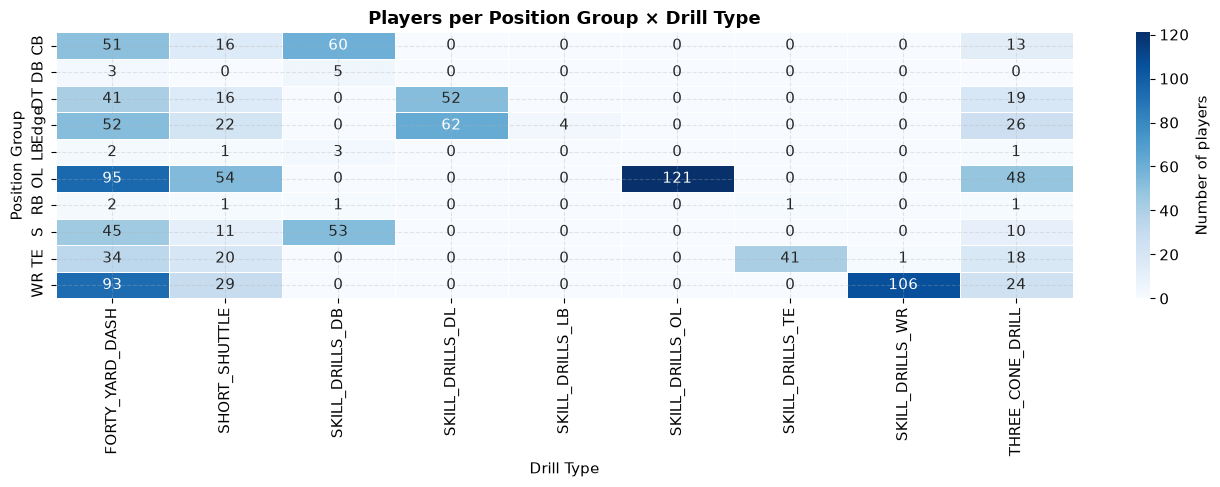

drill_type,FORTY_YARD_DASH,SHORT_SHUTTLE,SKILL_DRILLS_DB,SKILL_DRILLS_DL,SKILL_DRILLS_LB,SKILL_DRILLS_OL,SKILL_DRILLS_TE,SKILL_DRILLS_WR,THREE_CONE_DRILL
position_group,,,,,,,,,
CB,51,16,60,0,0,0,0,0,13
DB,3,0,5,0,0,0,0,0,0
DT,41,16,0,52,0,0,0,0,19
Edge,52,22,0,62,4,0,0,0,26
LB,2,1,3,0,0,0,0,0,1
OL,95,54,0,0,0,121,0,0,48
RB,2,1,1,0,0,0,1,0,1
S,45,11,53,0,0,0,0,0,10
TE,34,20,0,0,0,0,41,1,18


In [9]:
if 'drill_type' in features_df.columns and 'position_group' in player_features.columns:
    # Merge drill info with position info
    drill_pos = features_df[['nfl_id', 'drill_type']].merge(
        pos_map, on='nfl_id', how='left'
    )
    if 'position_group' in drill_pos.columns:
        pivot = (
            drill_pos.groupby(['position_group', 'drill_type'])['nfl_id']
            .nunique()
            .unstack(fill_value=0)
        )

        fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns) * 1.5), max(5, len(pivot) * 0.5)))
        sns.heatmap(
            pivot, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Number of players'},
        )
        ax.set_title('Players per Position Group × Drill Type', fontweight='bold')
        ax.set_xlabel('Drill Type')
        ax.set_ylabel('Position Group')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'position_drill_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show()

        display(pivot)
else:
    print('Cannot build drill-position heatmap: missing columns.')

## 9. Feature Correlation Within Position Groups

Within each position group, which tracking features are most correlated with each other?
Highly correlated features may be redundant.

C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:215: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = scipy_stats.spearmanr(x_data, y_data)
C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:215: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = scipy_stats.spearmanr(x_data, y_data)
C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:215: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = scipy_stats.spearmanr(x_data, y_data)
C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:215: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = scipy_stats.spearmanr(x_data, y_data)
C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:215

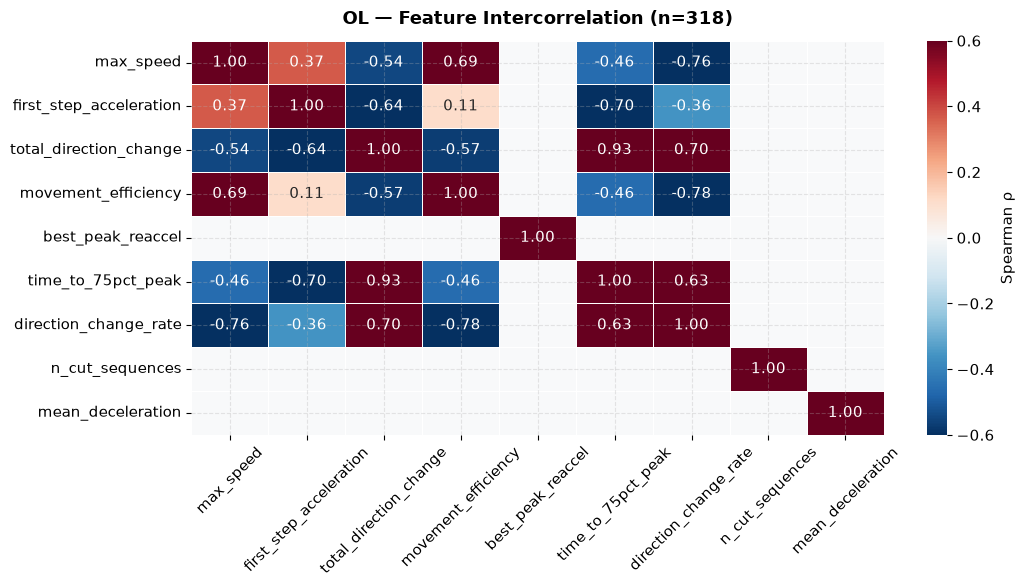

C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:215: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = scipy_stats.spearmanr(x_data, y_data)
C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:215: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = scipy_stats.spearmanr(x_data, y_data)
C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:215: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = scipy_stats.spearmanr(x_data, y_data)
C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:215: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = scipy_stats.spearmanr(x_data, y_data)
C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:215

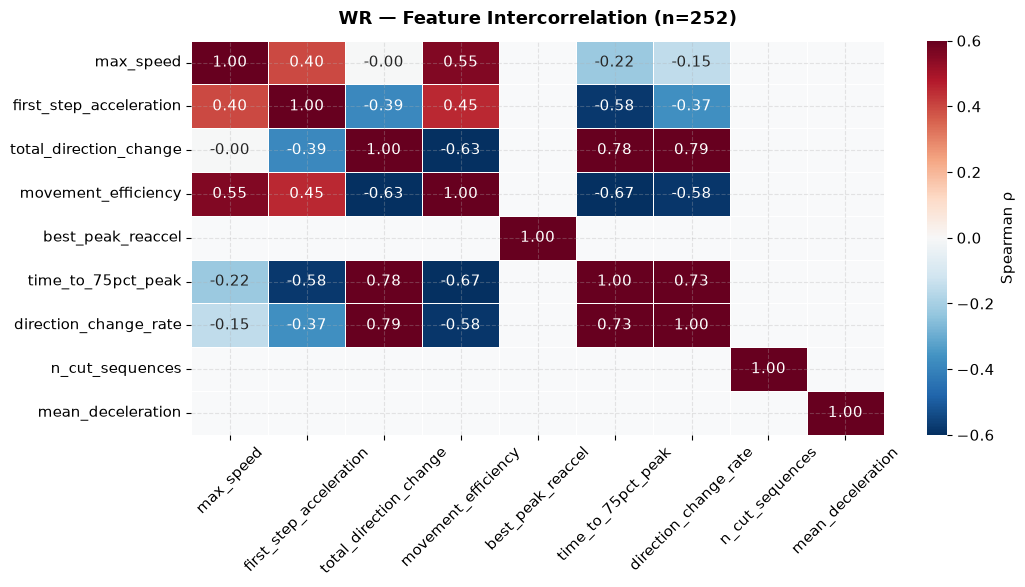

C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:215: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = scipy_stats.spearmanr(x_data, y_data)
C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:215: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = scipy_stats.spearmanr(x_data, y_data)
C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:215: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = scipy_stats.spearmanr(x_data, y_data)
C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:215: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = scipy_stats.spearmanr(x_data, y_data)
C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\src\statistics.py:215

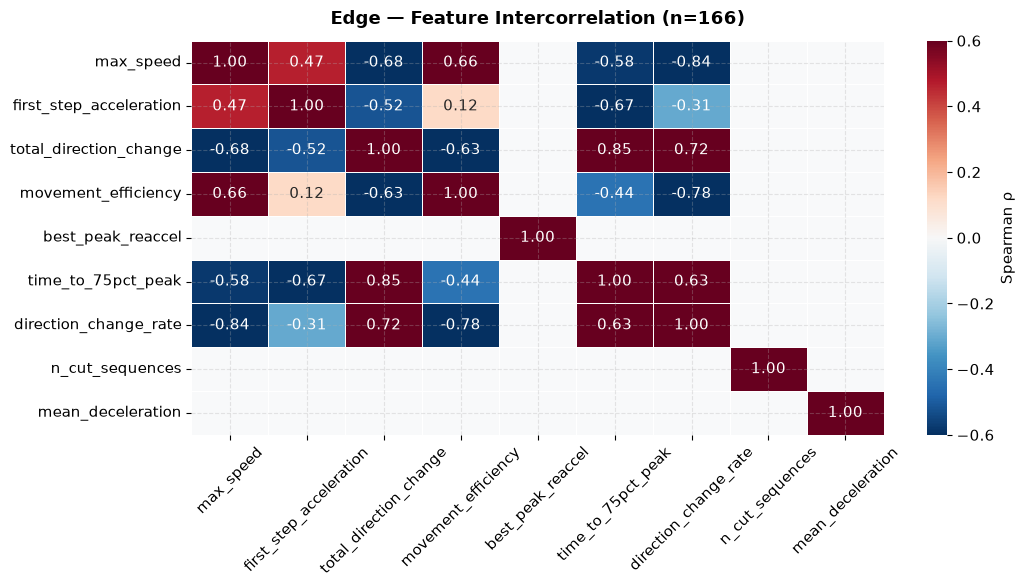

In [10]:
from src.statistics import correlation_matrix
from src.visualization import plot_correlation_heatmap

key_feats = [
    c for c in [
        'max_speed', 'first_step_acceleration', 'total_direction_change',
        'movement_efficiency', 'best_peak_reaccel', 'time_to_75pct_peak',
        'direction_change_rate', 'n_cut_sequences', 'mean_deceleration',
    ] if c in player_features.columns
]

if len(key_feats) >= 3 and 'position_group' in player_features.columns:
    for group in viable_groups[:3]:  # limit to top 3 viable groups
        group_data = player_features[player_features['position_group'] == group]
        n = len(group_data)
        if n < MIN_SAMPLE_SIZE:
            continue

        # Intra-feature correlation matrix
        avail_feats = [f for f in key_feats if f in group_data.columns]
        corr_mat = correlation_matrix(group_data, x_cols=avail_feats, y_cols=avail_feats)

        if not corr_mat.empty:
            plot_correlation_heatmap(
                corr_mat,
                title=f'{group} — Feature Intercorrelation (n={n})',
                filename=f'feature_intercorr_{group}.png',
            )
            plt.show()
else:
    print('Insufficient features or position groups for correlation analysis.')

## 10. Summary: Most Promising Position × Drill × Feature Combinations

Based on the analysis above, summarize what looks promising.

In [11]:
print("""
=== POSITION × DRILL × FEATURE SUMMARY ===

This is based on the EDA above. Fill in observations after running the notebook.

Each row below should be completed with ACTUAL numbers from the cells above.
Do not invent values.
""")

# Print sample sizes for each position × drill combination
if 'drill_type' in features_df.columns and 'position_group' in player_features.columns:
    drill_pos_summary = (
        features_df[['nfl_id', 'drill_type']]
        .merge(pos_map, on='nfl_id', how='left')
        .groupby(['position_group', 'drill_type'])['nfl_id']
        .nunique()
        .reset_index(name='n_players')
        .query(f'n_players >= {MIN_SAMPLE_SIZE}')
        .sort_values(['position_group', 'n_players'], ascending=[True, False])
    )
    print('Position × Drill combinations with sufficient sample size:')
    display(drill_pos_summary)
else:
    print('NOT YET COMPUTED — run cells above first.')


=== POSITION × DRILL × FEATURE SUMMARY ===

This is based on the EDA above. Fill in observations after running the notebook.

Each row below should be completed with ACTUAL numbers from the cells above.
Do not invent values.

Position × Drill combinations with sufficient sample size:


,position_group,drill_type,n_players
2,CB,SKILL_DRILLS_DB,60
0,CB,FORTY_YARD_DASH,51
1,CB,SHORT_SHUTTLE,16
3,CB,THREE_CONE_DRILL,13
8,DT,SKILL_DRILLS_DL,52
6,DT,FORTY_YARD_DASH,41
9,DT,THREE_CONE_DRILL,19
7,DT,SHORT_SHUTTLE,16
12,Edge,SKILL_DRILLS_DL,62
10,Edge,FORTY_YARD_DASH,52
